In [1]:
import jax
import jax.numpy as jnp
import jax.random as random
import matplotlib.pyplot as plt
import sys
import math
from jaxtyping import Float, Array, PRNGKeyArray

jax.config.update("jax_enable_x64", True)
sys.path.insert(0, "..")
Tensor = Float[Array, "..."]

In [2]:
plt.rcParams["svg.fonttype"] = "none"
## Set up LaTeX fonts
plt.rcParams.update(
    {
        "text.usetex": True,
        # "font.family": "serif",
        # "font.serif": ["Computer Modern Roman"],
        # "font.size": 14,
    }
)

# Defining the problem

In [105]:
from ctt.bases import make_canonical_polynomials, make_fourier, make_legendre_polynomials, make_chebyshev_polynomials

d = 4
n_features = 2
basis = make_canonical_polynomials(dim=n_features)
# basis = make_legendre_polynomials(dim=n_features)
# basis = make_chebyshev_polynomials(dim=n_features)
# basis = make_fourier(n_features)
# basis = lambda x: jnp.asarray([1., jax.nn.leaky_relu(x)])
key = random.PRNGKey(42)

In [106]:
def lift(x: Float[Array, "d"]) -> Float[Array, "m"]:
    # return jnp.hstack((jnp.zeros((1,)), x))
    return x

def retraction(x: Float[Array, "m"]) -> Float[Array, "o"]:
    return jnp.asarray((x[0],))

d_lift = jax.eval_shape(lift, jax.ShapeDtypeStruct((d,), dtype=float)).shape[0]
bases = [basis]*d_lift

In [107]:
from ctt.model import _eval_bases

def _eval_tensor(tensor: Tensor, x: Float[Array, "d"]) -> Float[Array, "d"]:
    features = _eval_bases(bases, x)
    y = tensor # (d, m, ..., m)
    for i in range(len(features)):
        y = jnp.einsum("di...,i->d...", y, features[i])
    return y

def _eval_ct(tensors: list[Tensor], x: Float[Array, "d"]) -> Float[Array, "d_o"]:
    def _body_fn(i: int, val: Float[Array, "d"]) -> Float[Array, "d"]:
        control = jax.lax.switch(i, [lambda u=u: u for u in tensors])
        return val + _eval_tensor(control, val)

    x = lift(x)
    val = jax.lax.fori_loop(0, len(tensors), _body_fn, x)
    val = retraction(val)
    return val

In [108]:
key, sample_key = random.split(key)
Sigma = random.normal(key=sample_key, shape=(d, d))
Sigma = Sigma @ Sigma.T / d

TARGET_FUNCTION = "bivariate"

@jax.jit
def target(x: Float[Array, "d"]) -> Float[Array, "m"]:
    if TARGET_FUNCTION == "standard-gaussian":
        val = jnp.exp(-jnp.sum(x**2) / 2)
    elif TARGET_FUNCTION == "heaviside":
        val = jnp.prod((x >= 0.0) * 1.0)
    elif TARGET_FUNCTION == "gaussian":
        val = jax.scipy.stats.multivariate_normal.pdf(
            x=x, mean=jnp.zeros_like(x), cov=Sigma
        )
    elif TARGET_FUNCTION == "henon-heiles":
        val = (
            0.5 * jnp.sum(x**2)
            + 0.2 * jnp.sum(x[:-1] * x[1:] ** 2 - x[:-1] ** 3)
            + 0.2**2 / 16 * jnp.sum((x[:-1] ** 2 + x[1:] ** 2) ** 2)
        )
    elif TARGET_FUNCTION == "bivariate":
        val = jnp.sum((x[:d//2] + x[d//2:]) ** 2) / (4*d)
    elif TARGET_FUNCTION == "mixture":
        val = jnp.sin(x[0] + x[2])*jnp.exp(x[3])*x[4] + jnp.sin(x[1]*x[2])*x[4]
    elif TARGET_FUNCTION == "hyperbolic":
        val = 1./(1.+jnp.prod(x))
    return jnp.atleast_1d(val)

# Learning

In [109]:
key, train_key, val_key = random.split(key, 3)

domain = (-1., 1.)
N_train = 100_000
X_train = random.uniform(key=train_key, shape=(N_train, d), minval=domain[0], maxval=domain[1])
# X_train = random.normal(key=train_key, shape=(N_train, d))
y_train = jax.vmap(target)(X_train)

N_val = 2000
X_val = random.uniform(key=val_key, shape=(N_val, d), minval=domain[0], maxval=domain[1])
# X_val = random.normal(key=val_key, shape=(N_val, d))
y_val = jax.vmap(target)(X_val)

num_steps = 2

In [110]:
def dataloader(arrays: list, batch_size: int, *, key: PRNGKeyArray):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = random.permutation(key, indices)
        (key,) = random.split(key, 1)
        start = 0
        end = batch_size
        while end <= dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size

In [111]:
import optax

@jax.jit
def compute_loss(tensors: list[Tensor],
                 x: Float[Array, "B d"],
                 y: Float[Array, "B d_o"]) -> float:
    B = x.shape[0]
    y_pred = jax.vmap(_eval_ct, in_axes=(None, 0))(tensors, x)
    loss = jnp.sum((y_pred - y)**2) / B
    return 0.5*loss

@jax.jit
def grad_loss(y_hat: Float[Array, "B d_o"], y: Float[Array, "B d_o"]) -> Float[Array, "B d_o"]:
    # return y_hat - y
    return (y_hat - y) / y_hat.shape[0]

In [112]:
import jax.flatten_util
import operator
import lineax
import numpy as np
from functools import partial
from ctt.tt import tt_to_full, full_to_tt_truncate, validate_ranks
from typing import Optional

def natural_gradient_descent(train_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                             val_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                             optimizer: optax.GradientTransformation,
                             params: list[Tensor],
                             opt_steps: int,
                             training_key: PRNGKeyArray,
                             batch_size: int = 64,
                             backtracking: bool = False,
                             damping_coeff: float = None,
                             rank: Optional[int] = 3,
                             truncate: bool = False,
                             retract: bool = False) -> tuple[list[Tensor], tuple[list[float], list[float]]]:
    X_train, y_train = train_dataset
    X_val, y_val = val_dataset
    opt_state = optimizer.init(params)
    train_losses = []
    val_losses = []

    def tree_mvp_dampen(mvp, lmbda=0.1):
        dampen_fcn = lambda mvp_, v_: mvp_ + lmbda * v_
        damp_mvp = lambda v: jax.tree.map(dampen_fcn, mvp(v), v)
        return damp_mvp

    def truncate(params, rank):
        new_params = []
        errors = []
        for i in range(len(params)):
            tensor = params[i]
            ranks = [1] + [rank]*(d_lift) + [1]
            ranks = validate_ranks(tensor.shape, ranks)
            truncated, error = full_to_tt_truncate(tensor, ranks)
            error /= jnp.linalg.norm(tensor)
            errors.append(error)
            new_params.append(tt_to_full(truncated))
        return new_params, errors

    def _natural_grad(tensors: list[Tensor],
                      x: Float[Array, "B d"],
                      y: Float[Array, "B d_o"]) -> tuple[list[Tensor], dict]:
        # solving the least-squares problem ||du/dtheta_k @ dir - grad L||
        y_pred = jax.vmap(_eval_ct, in_axes=(None, 0))(tensors, x)
        grad_losses = grad_loss(y_pred, y)
        J = jax.vmap(jax.jacfwd(_eval_ct), in_axes=(None, 0))(tensors, x)
        def _block_projection(jac: Tensor) -> tuple[Tensor, Float[Array, "m"]]:
            shape = jac.shape
            jac = jnp.reshape(jac, (jac.shape[0]*jac.shape[1],-1)) # (B*d_o, n_params)
            # ngrad, resid, rank, s = jnp.linalg.lstsq(jac, grad_losses.ravel(), rcond=damping_coeff)
            # p = s / jnp.linalg.norm(s, ord=1)
            # jax.debug.print("Rnage of singular value (k={k}): [{a}, {b}], rank={rank}, effective rank={eff_rank}",
            #                 k=k,
            #                 a=jnp.min(s),
            #                 b=jnp.max(s),
            #                 rank=rank,
            #                 eff_rank=jnp.exp(-jnp.sum(p*jnp.log(p))))
            G = jac.T @ jac / x.shape[0] # WARN: don't forget to divide by the number of samples!
            b = jac.T @ grad_losses.ravel()
            D = jnp.eye(G.shape[0])
            s = jnp.linalg.eigvalsh(G, symmetrize_input=False)[::-1]
            ngrad = jnp.linalg.solve(G + damping_coeff*D, b)
            # ngrad = jax.scipy.sparse.linalg.bicgstab(lambda x: (G+damping_coeff*D)@x, b, tol=1e-12)[0]
            resid = jnp.linalg.norm(jac @ ngrad - grad_losses.ravel())**2
            ngrad = jnp.reshape(ngrad, shape[2:])

            # check if the truncation perturbs the algorithm
            if truncate:
                ranks = [1] + [rank]*d_lift + [1]
                ranks = validate_ranks(shape[2:], ranks)
                truncated_ngrad, _ = full_to_tt_truncate(ngrad, ranks)
                approx_ngrad = tt_to_full(truncated_ngrad)
                approx_resid = jnp.linalg.norm(jac @ approx_ngrad.ravel() - grad_losses.ravel())**2
                error = (resid, approx_resid)
                ngrad = approx_ngrad
                # error = 0.
            return ngrad, s, error
        
        ngrads, s, errors = zip(*[_block_projection(J[k]) for k in range(len(tensors))])
        ngrads = list(ngrads)
        return ngrads, {"singular_values": s},# "errors": errors}

    @jax.jit
    def step(tensors: list[Tensor],
             opt_state: optax.OptState,
             x: Float[Array, "B d"],
             y: Float[Array, "B d"]):
        loss = compute_loss(tensors, x, y)
        ngrad, info = _natural_grad(tensors, x, y)
        if backtracking:
            updates, opt_state = optimizer.update(ngrad, opt_state, tensors, value=loss, grad=ngrad, value_fn=lambda p: compute_loss(p, x,y))
        else:
            updates, opt_state = optimizer.update(ngrad, opt_state, tensors)
        params = optax.apply_updates(tensors, updates)
        # compute the singular values of each unfolding tensor
        # info["params_sv"] = []
        # for i in range(len(params)):
        #     singular_values = []
        #     tensor = params[i]
        #     for j in range(len(tensor)):
        #         unfolded = jnp.reshape(tensor, (math.prod(tensor.shape[:j+1]), -1))
        #         singular_values.append(jnp.linalg.svdvals(unfolded))
        #     info["params_sv"].append(singular_values)

        if retract:
            params, errors = truncate(params, rank=rank)
            info["truncation_errors"] = errors
        return params, opt_state, loss, info

    learning_rates = []
    infos = []
    for i, (x, y) in zip(range(opt_steps), dataloader((X_train, y_train), batch_size, key=training_key)):
        params, opt_state, l2_error, info = step(params, 
                                                 opt_state, 
                                                 x,
                                                 y)
        val_loss = compute_loss(params, X_val, y_val)
        train_losses.append(l2_error)
        val_losses.append(val_loss)
        infos.append(info)
        if backtracking:
            learning_rates.append(opt_state[1].learning_rate)
        if i % 5 == 0:
            # errors = info["errors"]
            errors = info.get("truncation_errors")
            # errors = list(map(float, errors))
            print(f"Iter {i} | Loss: {l2_error:.3e} | Val loss: {val_loss:.3e} | Errors: {errors}")
            # print(f"Iter {i} | Loss: {l2_error:.3e} | Val loss: {val_loss:.3e}")


    return params, (train_losses, val_losses), learning_rates, infos

def gradient_descent(train_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                    val_dataset: tuple[Float[Array, "B d"], Float[Array, "B d_o"]],
                    optimizer: optax.GradientTransformation,
                    params: list[Tensor],
                    opt_steps: int,
                    training_key: PRNGKeyArray,
                    batch_size: int = 64,
                    backtracking: bool = False) -> tuple[list[Tensor], tuple[list[float], list[float]]]:
    X_train, y_train = train_dataset
    X_val, y_val = val_dataset
    opt_state = optimizer.init(params)
    train_losses = []
    val_losses = []
    
    @jax.jit
    def step(tensors: list[Tensor],
             opt_state: optax.OptState,
             x: Float[Array, "B d"],
             y: Float[Array, "B d"]):
        loss, grads = jax.value_and_grad(compute_loss)(tensors, x, y)
        if backtracking:
            updates, opt_state = optimizer.update(grads, opt_state, tensors, value=loss, grad=grads, value_fn=lambda p: compute_loss(p, x,y))
        else:
            updates, opt_state = optimizer.update(grads, opt_state, tensors)
        params = optax.apply_updates(tensors, updates)
        return params, opt_state, loss

    learning_rates = []
    for i, (x, y) in zip(range(opt_steps), dataloader((X_train, y_train), batch_size, key=training_key)):
        params, opt_state, l2_error = step(params, 
                                            opt_state, 
                                            x,
                                            y)
        val_loss = compute_loss(params, X_val, y_val)
        train_losses.append(l2_error)
        val_losses.append(val_loss)
        if backtracking:
            if len(opt_state) > 1 and hasattr(opt_state[1], "learning_rate"):
                lr = getattr(opt_state[1], "learning_rate")
                learning_rates.append(lr)
        if i % 5 == 0:
            print(f"Iter {i} | Loss: {l2_error:.3e} | Val loss: {val_loss:.3e}")

    return params, (train_losses, val_losses), learning_rates

In [113]:
from ctt.tt import tt_randn, tt_mul_scalar, tt_orth_right
key, *control_keys = random.split(key, num_steps+1)
key, training_key = random.split(key)

init_controls = [
    math.sqrt(2/(num_steps*n_features**d_lift))*random.normal(key=control_key, shape=(d_lift,) + (n_features,)*d_lift)
    for control_key in control_keys
]
rank = 3
ranks = [1] + [rank]*(d_lift) + [1]
init_controls = list(map(lambda x: full_to_tt_truncate(x, ranks)[0], init_controls))
init_controls = list(map(tt_to_full, init_controls))
# init_controls = [
#     tt_mul_scalar(tt_randn(control_key, [d_lift] + [n_features] * d_lift, ranks), math.sqrt(2/(num_steps*n_features**d_lift)))
#     for control_key in control_keys
# ]
# init_controls = list(map(tt_orth_right, init_controls))
# init_controls = list(map(tt_to_full, init_controls))
print(list(map(jnp.linalg.norm, init_controls)))

[Array(1.68835751, dtype=float64), Array(1.74584286, dtype=float64)]


## Natural gradient descent

In [120]:
optimizer = optax.chain(
    optax.sgd(learning_rate=1.),
    # optax.scale_by_backtracking_linesearch(max_backtracking_steps=20)
    optax.scale_by_zoom_linesearch(max_linesearch_steps=20, max_learning_rate=1., initial_guess_strategy="one")
)

params_ng, (train_losses_ng, val_losses_ng), learning_rates_ng, infos = natural_gradient_descent(train_dataset=(X_train, y_train),
                                                                              val_dataset=(X_val, y_val),
                                                                              optimizer=optimizer,
                                                                              params=init_controls,
                                                                              opt_steps=20_000,
                                                                              training_key=training_key,
                                                                              batch_size=128,
                                                                              backtracking=True,
                                                                              damping_coeff=1e-4,
                                                                              rank=rank,
                                                                              truncate=False,
                                                                              retract=True)

Iter 0 | Loss: 2.140e-01 | Val loss: 3.994e-03 | Errors: [Array(0.44568538, dtype=float64), Array(0.47845851, dtype=float64)]
Iter 5 | Loss: 1.148e-03 | Val loss: 9.908e-04 | Errors: [Array(0.26588339, dtype=float64), Array(0.0251734, dtype=float64)]
Iter 10 | Loss: 5.256e-04 | Val loss: 6.210e-04 | Errors: [Array(0.15205976, dtype=float64), Array(0.01551515, dtype=float64)]
Iter 15 | Loss: 4.021e-04 | Val loss: 3.813e-04 | Errors: [Array(0.13305173, dtype=float64), Array(0.01424751, dtype=float64)]
Iter 20 | Loss: 3.018e-04 | Val loss: 3.899e-04 | Errors: [Array(0.14062737, dtype=float64), Array(0.00817639, dtype=float64)]
Iter 25 | Loss: 2.022e-04 | Val loss: 2.744e-04 | Errors: [Array(0.07945161, dtype=float64), Array(0.00721638, dtype=float64)]
Iter 30 | Loss: 4.889e-04 | Val loss: 5.768e-04 | Errors: [Array(0.13402757, dtype=float64), Array(0.0332918, dtype=float64)]
Iter 35 | Loss: 7.208e-03 | Val loss: 2.521e-03 | Errors: [Array(0.21936324, dtype=float64), Array(0.04631056, dtyp

## Adam

In [14]:
optimizer = optax.chain(
    optax.adam(learning_rate=1.),
    # optax.scale_by_backtracking_linesearch(max_backtracking_steps=20)
    optax.scale_by_zoom_linesearch(max_linesearch_steps=20, initial_guess_strategy="keep")
)

params_gd, (train_losses_gd, val_losses_gd), learning_rates_gd = gradient_descent(train_dataset=(X_train, y_train),
                                                                              val_dataset=(X_val, y_val),
                                                                              optimizer=optimizer,
                                                                              params=init_controls,
                                                                              opt_steps=20_000,
                                                                              training_key=training_key,
                                                                              batch_size=128,
                                                                              backtracking=True)

Iter 0 | Loss: 2.140e-01 | Val loss: 4.822e-02
Iter 5 | Loss: 1.154e-02 | Val loss: 9.852e-03
Iter 10 | Loss: 9.566e-03 | Val loss: 7.270e-03
Iter 15 | Loss: 6.276e-03 | Val loss: 6.253e-03
Iter 20 | Loss: 4.373e-03 | Val loss: 4.688e-03
Iter 25 | Loss: 5.012e-03 | Val loss: 3.605e-03
Iter 30 | Loss: 3.262e-03 | Val loss: 3.413e-03
Iter 35 | Loss: 2.693e-03 | Val loss: 3.150e-03
Iter 40 | Loss: 2.739e-03 | Val loss: 2.208e-03
Iter 45 | Loss: 2.430e-03 | Val loss: 1.934e-03
Iter 50 | Loss: 2.674e-03 | Val loss: 1.755e-03
Iter 55 | Loss: 1.304e-03 | Val loss: 1.496e-03
Iter 60 | Loss: 1.476e-03 | Val loss: 1.292e-03
Iter 65 | Loss: 1.127e-03 | Val loss: 1.068e-03
Iter 70 | Loss: 1.339e-03 | Val loss: 9.212e-04
Iter 75 | Loss: 7.266e-04 | Val loss: 8.694e-04
Iter 80 | Loss: 8.514e-04 | Val loss: 7.291e-04
Iter 85 | Loss: 6.974e-04 | Val loss: 6.291e-04
Iter 90 | Loss: 6.436e-04 | Val loss: 5.901e-04
Iter 95 | Loss: 5.725e-04 | Val loss: 5.705e-04
Iter 100 | Loss: 5.694e-04 | Val loss: 5.2

## L-BFGS

In [15]:
optimizer = optax.lbfgs(memory_size=10,
                        scale_init_precond=False,
                        linesearch=optax.scale_by_zoom_linesearch(max_linesearch_steps=20,
                                                                  increase_factor=1.5,
                                                                  initial_guess_strategy="one"))

params_lbfgs, (train_losses_lbfgs, val_losses_lbfgs), learning_rates_lbfgs = gradient_descent(train_dataset=(X_train, y_train),
                                                                              val_dataset=(X_val, y_val),
                                                                              optimizer=optimizer,
                                                                              params=init_controls,
                                                                              opt_steps=20_000,
                                                                              training_key=training_key,
                                                                              batch_size=128,
                                                                              backtracking=True)

Iter 0 | Loss: 2.140e-01 | Val loss: 4.459e-02
Iter 5 | Loss: 4.430e-03 | Val loss: 2.742e-03
Iter 10 | Loss: 1.986e-03 | Val loss: 1.892e-03
Iter 15 | Loss: 1.947e-03 | Val loss: 1.693e-03
Iter 20 | Loss: 1.316e-03 | Val loss: 1.404e-03
Iter 25 | Loss: 1.800e-03 | Val loss: 1.483e-03
Iter 30 | Loss: 1.231e-03 | Val loss: 1.190e-03
Iter 35 | Loss: 7.770e-04 | Val loss: 1.112e-03
Iter 40 | Loss: 9.281e-04 | Val loss: 1.031e-03
Iter 45 | Loss: 1.043e-03 | Val loss: 9.879e-04
Iter 50 | Loss: 1.459e-03 | Val loss: 9.163e-04
Iter 55 | Loss: 1.003e-03 | Val loss: 8.412e-04
Iter 60 | Loss: 8.297e-04 | Val loss: 6.745e-04
Iter 65 | Loss: 5.123e-04 | Val loss: 5.087e-04
Iter 70 | Loss: 4.828e-04 | Val loss: 4.062e-04
Iter 75 | Loss: 3.601e-04 | Val loss: 3.525e-04
Iter 80 | Loss: 3.090e-04 | Val loss: 2.910e-04
Iter 85 | Loss: 1.930e-04 | Val loss: 2.638e-04
Iter 90 | Loss: 2.684e-04 | Val loss: 2.450e-04
Iter 95 | Loss: 2.135e-04 | Val loss: 2.262e-04
Iter 100 | Loss: 2.047e-04 | Val loss: 2.2

## BFGS

In [16]:
import jaxopt

solver = jaxopt.BFGS(fun=compute_loss)
params = init_controls
batch_size = 512
X, y = X_train[:batch_size], y_train[:batch_size]
state = solver.init_state(params, x=X, y=y)
val_losses_bfgs = []

for k in range(10_000):
    params, state = solver.update(params, state, x=X, y=y)
    val_loss = compute_loss(params, x=X_val, y=y_val)
    val_losses_bfgs.append(val_loss)
    if k % 5 == 0:
        print(f"Iter {k} | Loss: {state.value:.3e} | Val loss: {val_loss:.3e}")

Iter 0 | Loss: 3.204e-02 | Val loss: 3.359e-02
Iter 5 | Loss: 2.462e-03 | Val loss: 2.683e-03
Iter 10 | Loss: 1.555e-03 | Val loss: 1.658e-03
Iter 15 | Loss: 1.333e-03 | Val loss: 1.401e-03
Iter 20 | Loss: 1.106e-03 | Val loss: 1.138e-03
Iter 25 | Loss: 1.011e-03 | Val loss: 1.126e-03
Iter 30 | Loss: 7.828e-04 | Val loss: 9.146e-04
Iter 35 | Loss: 5.232e-04 | Val loss: 5.873e-04
Iter 40 | Loss: 4.189e-04 | Val loss: 4.904e-04
Iter 45 | Loss: 3.331e-04 | Val loss: 3.617e-04
Iter 50 | Loss: 2.954e-04 | Val loss: 3.328e-04
Iter 55 | Loss: 2.482e-04 | Val loss: 3.004e-04
Iter 60 | Loss: 2.238e-04 | Val loss: 2.686e-04
Iter 65 | Loss: 2.056e-04 | Val loss: 2.320e-04
Iter 70 | Loss: 1.850e-04 | Val loss: 2.083e-04
Iter 75 | Loss: 1.703e-04 | Val loss: 2.043e-04
Iter 80 | Loss: 1.481e-04 | Val loss: 1.885e-04
Iter 85 | Loss: 1.263e-04 | Val loss: 1.592e-04
Iter 90 | Loss: 1.151e-04 | Val loss: 1.748e-04
Iter 95 | Loss: 9.458e-05 | Val loss: 1.554e-04
Iter 100 | Loss: 8.447e-05 | Val loss: 1.4

## Plotting the error

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


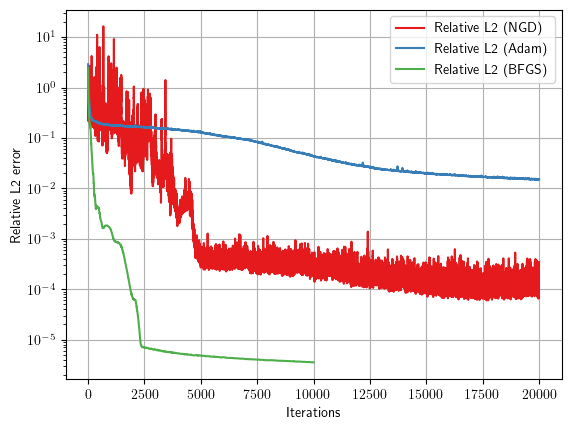

In [121]:
from matplotlib import colormaps
from cycler import cycler

y_val_norm = jnp.mean(optax.l2_loss(jnp.zeros_like(y_val), y_val))

# plot NGD losses
val_losses_ng = jnp.asarray(val_losses_ng)
val_losses_gd = jnp.asarray(val_losses_gd)
val_losses_lbfgs = jnp.asarray(val_losses_lbfgs)
val_losses_bfgs = jnp.asarray(val_losses_bfgs)

plt.rcParams.update({"axes.prop_cycle": cycler(color=colormaps["Set1"].colors)})

plt.semilogy(jnp.arange(len(val_losses_ng)),
             jnp.sqrt(val_losses_ng/y_val_norm),
             label="Relative L2 (NGD)")
plt.semilogy(jnp.arange(len(val_losses_gd)),
             jnp.sqrt(val_losses_gd/y_val_norm),
             label="Relative L2 (Adam)")
# plt.semilogy(jnp.arange(len(val_losses_lbfgs)),
#              jnp.sqrt(val_losses_lbfgs/y_val_norm),
#              label="Relative L2 (LBFGS)")
plt.semilogy(jnp.arange(len(val_losses_bfgs)),
             jnp.sqrt(val_losses_bfgs/y_val_norm),
             label="Relative L2 (BFGS)")

plt.grid()
plt.legend()
plt.xlabel("Iterations")
plt.ylabel("Relative L2 error")
plt.savefig("error.eps", format="eps", dpi=1200)
# plt.clf()
# plt.cla()

# # plot learning rates
# plt.semilogy(learning_rates_ng)
# plt.grid()
# plt.xlabel("Iterations")
# plt.ylabel("Learning rate")

In [122]:
jnp.save("ngd_retract_bivariate_d4_r3.npy", jnp.sqrt(val_losses_ng/y_val_norm))

## Evolution of the singular values

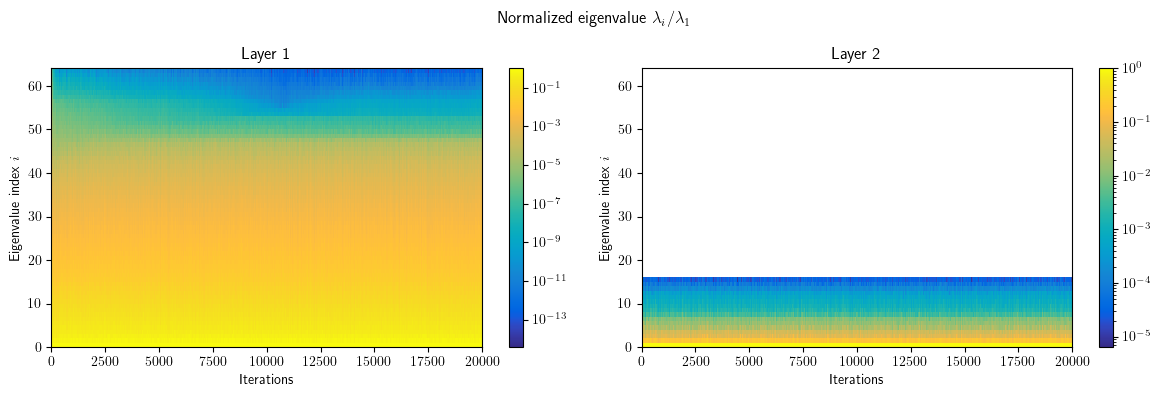

In [67]:
from matplotlib.colors import LinearSegmentedColormap

cm_data = [[0.2081, 0.1663, 0.5292], [0.2116238095, 0.1897809524, 0.5776761905], 
 [0.212252381, 0.2137714286, 0.6269714286], [0.2081, 0.2386, 0.6770857143], 
 [0.1959047619, 0.2644571429, 0.7279], [0.1707285714, 0.2919380952, 
  0.779247619], [0.1252714286, 0.3242428571, 0.8302714286], 
 [0.0591333333, 0.3598333333, 0.8683333333], [0.0116952381, 0.3875095238, 
  0.8819571429], [0.0059571429, 0.4086142857, 0.8828428571], 
 [0.0165142857, 0.4266, 0.8786333333], [0.032852381, 0.4430428571, 
  0.8719571429], [0.0498142857, 0.4585714286, 0.8640571429], 
 [0.0629333333, 0.4736904762, 0.8554380952], [0.0722666667, 0.4886666667, 
  0.8467], [0.0779428571, 0.5039857143, 0.8383714286], 
 [0.079347619, 0.5200238095, 0.8311809524], [0.0749428571, 0.5375428571, 
  0.8262714286], [0.0640571429, 0.5569857143, 0.8239571429], 
 [0.0487714286, 0.5772238095, 0.8228285714], [0.0343428571, 0.5965809524, 
  0.819852381], [0.0265, 0.6137, 0.8135], [0.0238904762, 0.6286619048, 
  0.8037619048], [0.0230904762, 0.6417857143, 0.7912666667], 
 [0.0227714286, 0.6534857143, 0.7767571429], [0.0266619048, 0.6641952381, 
  0.7607190476], [0.0383714286, 0.6742714286, 0.743552381], 
 [0.0589714286, 0.6837571429, 0.7253857143], 
 [0.0843, 0.6928333333, 0.7061666667], [0.1132952381, 0.7015, 0.6858571429], 
 [0.1452714286, 0.7097571429, 0.6646285714], [0.1801333333, 0.7176571429, 
  0.6424333333], [0.2178285714, 0.7250428571, 0.6192619048], 
 [0.2586428571, 0.7317142857, 0.5954285714], [0.3021714286, 0.7376047619, 
  0.5711857143], [0.3481666667, 0.7424333333, 0.5472666667], 
 [0.3952571429, 0.7459, 0.5244428571], [0.4420095238, 0.7480809524, 
  0.5033142857], [0.4871238095, 0.7490619048, 0.4839761905], 
 [0.5300285714, 0.7491142857, 0.4661142857], [0.5708571429, 0.7485190476, 
  0.4493904762], [0.609852381, 0.7473142857, 0.4336857143], 
 [0.6473, 0.7456, 0.4188], [0.6834190476, 0.7434761905, 0.4044333333], 
 [0.7184095238, 0.7411333333, 0.3904761905], 
 [0.7524857143, 0.7384, 0.3768142857], [0.7858428571, 0.7355666667, 
  0.3632714286], [0.8185047619, 0.7327333333, 0.3497904762], 
 [0.8506571429, 0.7299, 0.3360285714], [0.8824333333, 0.7274333333, 0.3217], 
 [0.9139333333, 0.7257857143, 0.3062761905], [0.9449571429, 0.7261142857, 
  0.2886428571], [0.9738952381, 0.7313952381, 0.266647619], 
 [0.9937714286, 0.7454571429, 0.240347619], [0.9990428571, 0.7653142857, 
  0.2164142857], [0.9955333333, 0.7860571429, 0.196652381], 
 [0.988, 0.8066, 0.1793666667], [0.9788571429, 0.8271428571, 0.1633142857], 
 [0.9697, 0.8481380952, 0.147452381], [0.9625857143, 0.8705142857, 0.1309], 
 [0.9588714286, 0.8949, 0.1132428571], [0.9598238095, 0.9218333333, 
  0.0948380952], [0.9661, 0.9514428571, 0.0755333333], 
 [0.9763, 0.9831, 0.0538]]

parula_map = LinearSegmentedColormap.from_list('parula', cm_data)

singular_values = [infos[k]["singular_values"] for k in range(len(infos))]
singular_values = list(zip(*singular_values))
singular_values = list(map(jnp.stack, singular_values))

nrows = math.ceil(num_steps / 2)
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(12, 4*nrows))

for k in range(num_steps):
    ax = axes.flat[k]
    sv = singular_values[k]
    normalised_sv = sv / sv[:, :1]
    c = ax.pcolormesh(normalised_sv.T, norm="log", cmap=parula_map, rasterized=True)
    ax.set_title(f"Layer {k+1}")
    ax.set_ylabel("Eigenvalue index $i$")
    ax.set_xlabel("Iterations")
    fig.colorbar(c, ax=ax)
fig.suptitle(r"Normalized eigenvalue $\lambda_i/\lambda_1$")
fig.tight_layout()
## access each axes object via axs.flat
for ax in axes.flat:
    ## check if something was plotted 
    if not bool(ax.has_data()):
        fig.delaxes(ax) ## delete if nothing is plotted in the axes obj

plt.savefig("eigenvalues.eps", format="eps")

In [31]:
from ctt.tt import full_to_tt_rounding, tt_ranks

epsilon = 1e-4
for i, layer in enumerate(params_ng):
    approximation, error = full_to_tt_rounding(layer, epsilon)
    print(f"Layer {i+1} | Ranks: {tt_ranks(approximation)} | A priori bound: {error:.3e}")

Layer 1 | Ranks: [1, 4, 5, 4, 2, 1] | A priori bound: 1.545e-10
Layer 2 | Ranks: [1, 4, 8, 4, 2, 1] | A priori bound: 0.000e+00


In [19]:
jnp.save("full_ngd.npy", jnp.sqrt(val_losses_ng/y_val_norm))
jnp.save("full_adam.npy", jnp.sqrt(val_losses_gd/y_val_norm))